In [16]:
import os
import pandas as pd
import numpy as np
import time
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error

In [17]:
# Load dataset
df = pd.read_csv(r'ucs_train_data.csv')

# Define features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
n, p = X.shape

# Split data into train and test sets
random_state = 2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

# Specify the folder to save results
save_folder = f"Bagging_regressor_results_{random_state}"
os.makedirs(save_folder, exist_ok=True)


In [18]:
from sklearn.ensemble import BaggingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
import time

# Define base estimator
base_model = LinearRegression()

# Define the Bagging Regressor
model = BaggingRegressor(estimator=base_model, random_state=2)

# Define parameter grid for Bagging
param_grid = {
    "n_estimators": [10, 50, 100],
    "max_samples": [0.5, 0.7,],
    "max_features": [0.5, 0.7, 1.0],
    "bootstrap": [True, False],
    "bootstrap_features": [False, True]
}

# Perform Grid Search with Cross-Validation
start_time = time.time()
gcv = GridSearchCV(model, param_grid, cv=5, scoring='r2', verbose=2)
gcv.fit(X_train, y_train)
end_time = time.time()
training_time = end_time - start_time


Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV] END bootstrap=True, bootstrap_features=False, max_features=0.5, max_samples=0.5, n_estimators=10; total time=   0.0s
[CV] END bootstrap=True, bootstrap_features=False, max_features=0.5, max_samples=0.5, n_estimators=10; total time=   0.0s
[CV] END bootstrap=True, bootstrap_features=False, max_features=0.5, max_samples=0.5, n_estimators=10; total time=   0.0s
[CV] END bootstrap=True, bootstrap_features=False, max_features=0.5, max_samples=0.5, n_estimators=10; total time=   0.0s
[CV] END bootstrap=True, bootstrap_features=False, max_features=0.5, max_samples=0.5, n_estimators=10; total time=   0.0s
[CV] END bootstrap=True, bootstrap_features=False, max_features=0.5, max_samples=0.5, n_estimators=50; total time=   0.0s
[CV] END bootstrap=True, bootstrap_features=False, max_features=0.5, max_samples=0.5, n_estimators=50; total time=   0.0s
[CV] END bootstrap=True, bootstrap_features=False, max_features=0.5, max_samples=0.5

In [19]:
# Convert to hours, minutes, and seconds
hours = training_time // 3600
minutes = (training_time % 3600) // 60
seconds = training_time % 60

# Save training time
training_time_path = os.path.join(save_folder, "training_time.txt")

# Print the formatted time
print(f"Training time:{hours:.0f} hours {minutes:.0f} minutes {seconds:.2f} seconds")

# Optionally, save the training time to a file
with open(training_time_path, "w") as file:
    file.write(f"Training time:{hours:.0f} hours {minutes:.0f} minutes {seconds:.2f} seconds")

Training time:0 hours 0 minutes 39.97 seconds


In [20]:
# Print best parameters
best_params = gcv.best_params_
print("Best Parameters:", best_params)
pd.DataFrame([best_params]).to_csv(os.path.join(save_folder, "best_params.csv"), index=False)

Best Parameters: {'bootstrap': False, 'bootstrap_features': True, 'max_features': 1.0, 'max_samples': 0.7, 'n_estimators': 100}


In [21]:
# Print and save cross-validation results
cv_results = pd.DataFrame(gcv.cv_results_)
print("Cross-Validation Results:\n", cv_results)
cv_results.to_csv(os.path.join(save_folder, "cv_results.csv"), index=False)

Cross-Validation Results:
     mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0        0.034738      0.008239         0.004509        0.001154   
1        0.096257      0.004292         0.006381        0.000676   
2        0.183812      0.003383         0.011604        0.000582   
3        0.020633      0.001241         0.002957        0.000724   
4        0.093062      0.002623         0.006621        0.000682   
..            ...           ...              ...             ...   
67       0.107014      0.003741         0.007287        0.000515   
68       0.206454      0.008302         0.011818        0.000972   
69       0.023765      0.001914         0.003477        0.000047   
70       0.107367      0.004769         0.006809        0.000563   
71       0.202402      0.009879         0.013011        0.001776   

    param_bootstrap  param_bootstrap_features  param_max_features  \
0              True                     False                 0.5   
1              Tru

In [22]:
cv_results.keys()

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_bootstrap', 'param_bootstrap_features', 'param_max_features',
       'param_max_samples', 'param_n_estimators', 'params',
       'split0_test_score', 'split1_test_score', 'split2_test_score',
       'split3_test_score', 'split4_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score'],
      dtype='object')

In [23]:
import os
import pandas as pd

# Extract the best hyperparameter combination
best_params = gcv.best_params_
fold_r2 = [cv_results[f'split{i}_test_score'].mean() for i in range(gcv.n_splits_)]
# Extract the R² for the best hyperparameter combination in each fold
best_fold_r2 = []

# Loop through each fold and get the R² for the best combination
for i in range(gcv.n_splits_):
    # Compare the parameter dictionary for each fold
    best_fold_r2.append(cv_results[f'split{i}_test_score'][cv_results['params'].apply(lambda x: x == best_params)].values[0])


# Print the R² for each fold
print("R2 for each fold:", fold_r2)
# Print the R² for the best combination in each fold
print("R² for the best combination in each fold:", best_fold_r2)

# Save the R² values for each fold to a CSV file
fold_r2_best = pd.DataFrame(fold_r2, columns=["Each fold R2"])
fold_r2_best["Best Combination R2"] = best_fold_r2
fold_r2_best.to_csv(os.path.join(save_folder, "r2_folds_best_combi.csv"), index=False)


print("R² values for each fold and best combination saved successfully.")


R2 for each fold: [0.8092953021133669, 0.9035549336430047, 0.7712015926477499, 0.7707042042854941, 0.654378334701751]
R² for the best combination in each fold: [0.8400638412111012, 0.9212090290539608, 0.7899314949686422, 0.8033785794188625, 0.6772637019287028]
R² values for each fold and best combination saved successfully.


In [24]:
best_model = gcv.best_estimator_

In [31]:
gcv.best_estimator_

BaggingRegressor(bootstrap=False, bootstrap_features=True,
                 estimator=LinearRegression(), max_samples=0.7,
                 n_estimators=100, random_state=2)

In [25]:
# Evaluate the model
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)
y_whole_pred = best_model.predict(X)


In [26]:
# Define the adjusted R² function
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Compute and save metrics
metrics = {
    "Train": {
        "R2": r2_score(y_train, y_train_pred),
        "Adj R2": adjusted_r2(r2_score(y_train, y_train_pred), len(y_train), X_train.shape[1]),  # Adjusted R2 for train
        "RMSE": root_mean_squared_error(y_train, y_train_pred),
        "MSE": mean_squared_error(y_train, y_train_pred),
        "MAE": mean_absolute_error(y_train, y_train_pred),
        "MAPE": mean_absolute_percentage_error(y_train, y_train_pred),
        "MaxE": np.max(np.abs(y_train - y_train_pred)),
        "MinE": np.min(np.abs(y_train - y_train_pred)),
    },
    "Test": {
        "R2": r2_score(y_test, y_test_pred),
        "Adj R2": adjusted_r2(r2_score(y_test, y_test_pred), len(y_test), X_test.shape[1]),  # Adjusted R2 for test
        "RMSE": root_mean_squared_error(y_test, y_test_pred),
        "MSE": mean_squared_error(y_test, y_test_pred),
        "MAE": mean_absolute_error(y_test, y_test_pred),
        "MAPE": mean_absolute_percentage_error(y_test, y_test_pred),
        "MaxE": np.max(np.abs(y_test - y_test_pred)),
        "MinE": np.min(np.abs(y_test - y_test_pred)),
    },
    "Whole": {
        "R2": r2_score(y, y_whole_pred),
        "Adj R2": adjusted_r2(r2_score(y, y_whole_pred), len(y), X.shape[1]),  # Adjusted R2 for whole dataset
        "RMSE": root_mean_squared_error(y, y_whole_pred),
        "MSE": mean_squared_error(y, y_whole_pred),
        "MAE": mean_absolute_error(y, y_whole_pred),
        "MAPE": mean_absolute_percentage_error(y, y_whole_pred),
        "MaxE": np.max(np.abs(y - y_whole_pred)),
        "MinE": np.min(np.abs(y - y_whole_pred)),
    }
}

# Save metrics to CSV
metrics_df = pd.DataFrame(metrics)
metrics_csv_path = os.path.join(save_folder, "metrics.csv")
metrics_df.to_csv(metrics_csv_path, index=True)

# Display the metrics DataFrame
metrics_df




,Train,Test,Whole
R2,0.836476,0.898314,0.844965
Adj R2,0.831770,0.885193,0.841421
RMSE,3.563061,2.241115,3.340785
MSE,12.695404,5.022596,11.160842
MAE,2.034797,1.545812,1.937000
MAPE,0.054672,0.043380,0.052414
MaxE,20.624835,8.955650,20.624835
MinE,0.038426,0.056915,0.038426


In [27]:
# Create a single Excel file with multiple sheets
excel_path = os.path.join(save_folder, "results.xlsx")
with pd.ExcelWriter(excel_path) as writer:
    pd.DataFrame({"y_test": y_test, "y_test_pred": y_test_pred}).to_excel(writer, sheet_name="Test", index=False)
    pd.DataFrame({"y_train": y_train, "y_train_pred": y_train_pred}).to_excel(writer, sheet_name="Train", index=False)
    pd.DataFrame({"y_whole": y, "y_whole_pred": y_whole_pred}).to_excel(writer, sheet_name="Whole", index=False)
    pd.DataFrame({"y_whole": y, "y_whole_pred": y_whole_pred}).to_excel(writer, sheet_name="Whole", index=False)

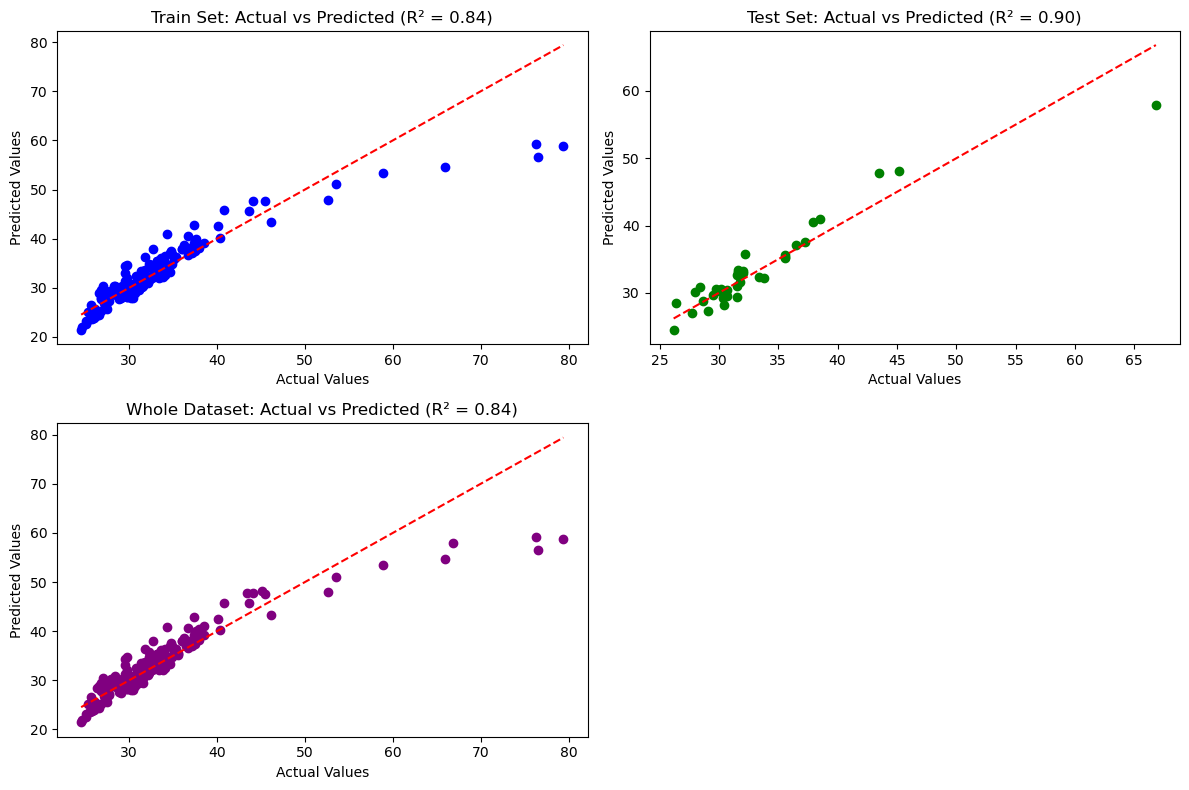

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Calculate R² for each dataset
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
whole_r2 = r2_score(y, y_whole_pred)

# Optional: Visualizing the actual vs predicted values for train, test, and whole dataset
plt.figure(figsize=(12, 8))

# Train Set
plt.subplot(2, 2, 1)
plt.scatter(y_train, y_train_pred, color='blue')
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='red', linestyle='--')
plt.title(f"Train Set: Actual vs Predicted (R² = {train_r2:.2f})")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

# Test Set
plt.subplot(2, 2, 2)
plt.scatter(y_test, y_test_pred, color='green')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title(f"Test Set: Actual vs Predicted (R² = {test_r2:.2f})")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

# Whole Dataset
plt.subplot(2, 2, 3)
plt.scatter(y, y_whole_pred, color='purple')
plt.plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='--')
plt.title(f"Whole Dataset: Actual vs Predicted (R² = {whole_r2:.2f})")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.tight_layout()
plt.savefig(os.path.join(save_folder, "Resutls.png"), dpi=500)
plt.show()



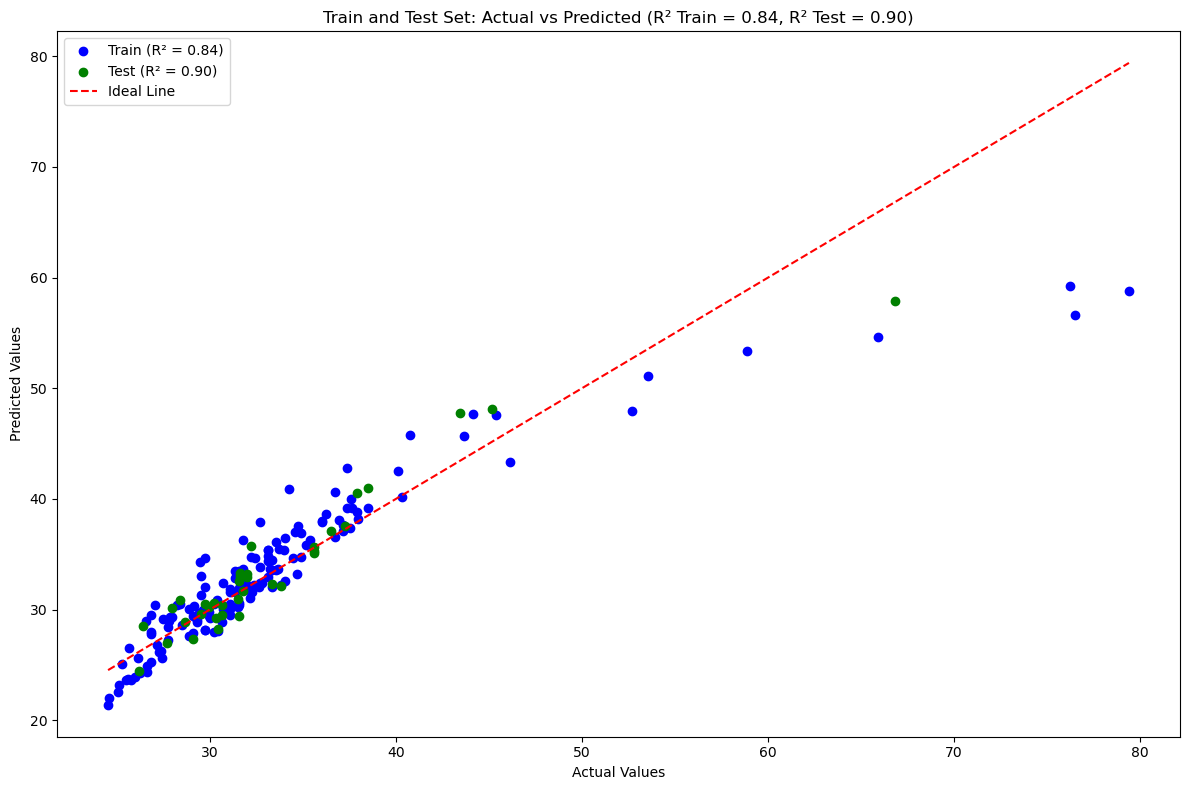

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score


# Optional: Visualizing the actual vs predicted values for train and test dataset in the same plot
plt.figure(figsize=(12, 8))

# Combined Plot for Train and Test Set
plt.subplot(1, 1, 1)  # Single plot for both Train and Test
plt.scatter(y_train, y_train_pred, color='blue', label=f'Train (R² = {train_r2:.2f})')
plt.scatter(y_test, y_test_pred, color='green', label=f'Test (R² = {test_r2:.2f})')
plt.plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='--', label='Ideal Line')
plt.title(f"Train and Test Set: Actual vs Predicted (R² Train = {train_r2:.2f}, R² Test = {test_r2:.2f})")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(save_folder, "Results_subplot.png"), dpi=500)
plt.show()


In [30]:

feature_importances = best_model.feature_importances_

# Convert to DataFrame for sorting and visualization
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)
feature_importance= os.path.join(save_folder, "feature_importance.csv")
# Plot feature importance as a bar chart
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='royalblue')
plt.xlabel("Feature Importance", fontsize=14, fontweight='bold')
plt.ylabel("Features", fontsize=14, fontweight='bold')
plt.title("Feature Importance in Random Forest", fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()  # To display the most important feature at the top
plt.savefig(os.path.join(save_folder, "feature_importance.png"),dpi=1000)
plt.show()


AttributeError: 'BaggingRegressor' object has no attribute 'feature_importances_'

In [ ]:

# Save the model
joblib.dump(best_model, os.path.join(save_folder, "best_model_random_forest.pkl"))

['random_forest_regressor_results_2\\best_model_random_forest.pkl']